# Optimal Transport Pairing in Flow Matching

In the baseline flow matching approach, we randomly pair latent samples with data samples. This notebook explores how **optimal transport (OT) pairings** can provide more structured couplings that improve training efficiency and sample quality.

## Motivation

When training flow matching models, we need to pair samples from the source distribution $\mu_1$ (latents) with samples from the target distribution $\mu_0$ (data). The choice of pairing affects:

- **Training dynamics:** How quickly the model learns
- **Flow straightness:** Whether trajectories are straight or curved
- **Sample quality:** The final distribution match


## Setup for Google Colab


In [ ]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    print("Installing dependencies...")
    !pip install -q pot geomloss
    
    # Download fm_utils.py
    import urllib.request
    url = "https://raw.githubusercontent.com/JChemseddine/fm_tutorial/main/fm_utils.py"
    urllib.request.urlretrieve(url, "fm_utils.py")
    print("Setup complete!")
else:
    # Local development - add parent directory to path
    import sys
    sys.path.insert(0, '..')

## Imports


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from fm_utils import (
    DEVICE,
    FlowConfig,
    compute_ema,
    euler_integrate,
    get_distribution,
    make_batch_sampler,
    make_latent_sampler,
    plot_points,
    plot_source_target_trajectories,
    plot_transport_lines,
    set_seed,
    train_flow,
    compute_distribution_metrics,
)

print(f"Using device: {DEVICE}")

Using device: cuda


## Optimal Transport: Theory

### The Discrete Kantorovich Problem

Given two sets of samples $\{x_i\}_{i=1}^N$ and $\{y_j\}_{j=1}^N$ with uniform weights, we want to find a coupling (matching) that minimizes the total transport cost:

$$
\min_{P \in U(a,b)} \sum_{i,j} C_{ij} P_{ij}
$$

where:
- $C_{ij} = \|x_i - y_j\|^2$ is the cost matrix (squared Euclidean distance)
- $P \in \mathbb{R}^{N \times N}$ is the transport plan with $P_{ij} \geq 0$
- $U(a,b)$ is the set of admissible couplings: $P\mathbf{1} = a$ and $P^\top\mathbf{1} = b$
- $a = b = \frac{1}{N}\mathbf{1}$ (uniform weights)

For equal-sized batches with uniform weights, the optimal plan reduces to a **permutation** - each source point is matched to exactly one target point.

### Computing OT Pairings

We use the POT (Python Optimal Transport) library which implements efficient algorithms for computing optimal transport plans.


## Implementation: Computing OT Pairings

Let's implement a function that computes optimal transport pairings between two batches of samples.

In [ ]:
def minibatch_ot_pairing(x0, x1):
    """
    Compute minibatch OT pairing between data (x0) and latents (x1).
    
    Uses the POT library to solve the optimal transport problem and returns
    the optimal permutation indices.
    
    Args:
        x0: Data batch (B, D) 
        x1: Latent batch (B, D)
    
    Returns:
        indices: (B,) permutation indices so x1[indices] is optimally paired with x0
        transport_plan: (B, B) transport matrix from the OT solution
    """
    import ot as pot_lib
    
    if x0.shape[0] != x1.shape[0]:
        raise ValueError(f"x0 and x1 must have same batch size. Got {x0.shape[0]} and {x1.shape[0]}")
    
    device = x0.device
    
    # Compute cost matrix: squared Euclidean distances
    with torch.no_grad():
        C = torch.cdist(x0, x1, p=2).pow(2).cpu().numpy()
        
        # Uniform weights for source and target
        a = pot_lib.unif(C.shape[0])
        b = pot_lib.unif(C.shape[1])
        
        # Solve optimal transport with exact EMD (Earth Mover's Distance)
        transport_plan = pot_lib.emd(a, b, C)
        
        # Convert back to torch
        P = torch.tensor(transport_plan, dtype=torch.float32, device=device)
        
        # TODO: Extract indices to reorder x1 to match x0
        # Hint: For each x0[i], find which x1[j] should be paired with it
        # Use argmax on the appropriate dimension of P
        indices = ???  # YOUR CODE HERE
    
    return indices, P

## Visualizing Random vs. OT Couplings

### A Two-Gaussian Example

To understand the difference between random and OT pairings, we construct a simple toy problem:

- **Source:** Two Gaussias with modes  at $(-2, -1)$ and $(2, -1)$
- **Target:** Two Gaussians with modes at $(2, 1)$ and $(-2, 1)$




---

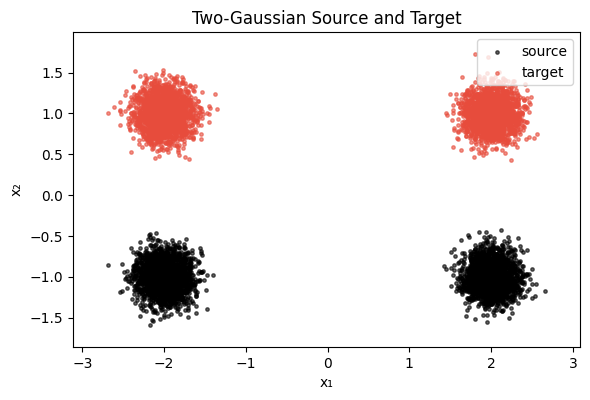

In [ ]:
import torch.distributions as D

set_seed(1)
np.random.seed(1)

source_means = torch.tensor([[-2.0, -1.0], [2.0, -1.0]], device=DEVICE, dtype=torch.float32)
target_means = torch.tensor([[2.0, 1.0], [-2.0, 1.0]], device=DEVICE, dtype=torch.float32)
cov_matrix = torch.eye(2, device=DEVICE, dtype=torch.float32) * 0.03

component_distribution = D.MultivariateNormal(
    loc=source_means,
    covariance_matrix=cov_matrix.expand(source_means.shape[0], -1, -1),
)
mixture_distribution = D.Categorical(torch.ones(source_means.shape[0], device=DEVICE))
base_sampler = D.MixtureSameFamily(mixture_distribution, component_distribution)

component_distribution_target = D.MultivariateNormal(
    loc=target_means,
    covariance_matrix=cov_matrix.expand(target_means.shape[0], -1, -1),
)
target_mixture = D.Categorical(torch.ones(target_means.shape[0], device=DEVICE))
target_sampler = D.MixtureSameFamily(target_mixture, component_distribution_target)

num_points = 4096
source_tensor = base_sampler.sample((num_points,))
target_tensor = target_sampler.sample((num_points,))

source_np = source_tensor.detach().cpu().numpy()
target_np = target_tensor.detach().cpu().numpy()

source_color = '#000000'
target_color = '#E74C3C'
line_color = '#0E2ECC'


fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(source_np[:, 0], source_np[:, 1], s=6, alpha=0.6, color=source_color, label='source')
ax.scatter(target_np[:, 0], target_np[:, 1], s=6, alpha=0.6, color=target_color, label='target')

x_min = min(source_np[:, 0].min(), target_np[:, 0].min())
x_max = max(source_np[:, 0].max(), target_np[:, 0].max())
y_min = min(source_np[:, 1].min(), target_np[:, 1].min())
y_max = max(source_np[:, 1].max(), target_np[:, 1].max())
range_x = max(x_max - x_min, 1.0)
range_y = max(y_max - y_min, 1.0)
pad_x = 0.08 * range_x
pad_y = 0.08 * range_y

ax.set_xlim(x_min - pad_x, x_max + pad_x)
ax.set_ylim(y_min - pad_y, y_max + pad_y)
ax.set_title('Two-Gaussian Source and Target')

ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


Let's create sample data from two Gaussians in each distribution:

### Comparing Coupling Strategies


/homes/numerik/chemseddine/scratch/miniconda3/envs/Main/lib/python3.10/site-packages/ot/lp/__init__.py:354: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


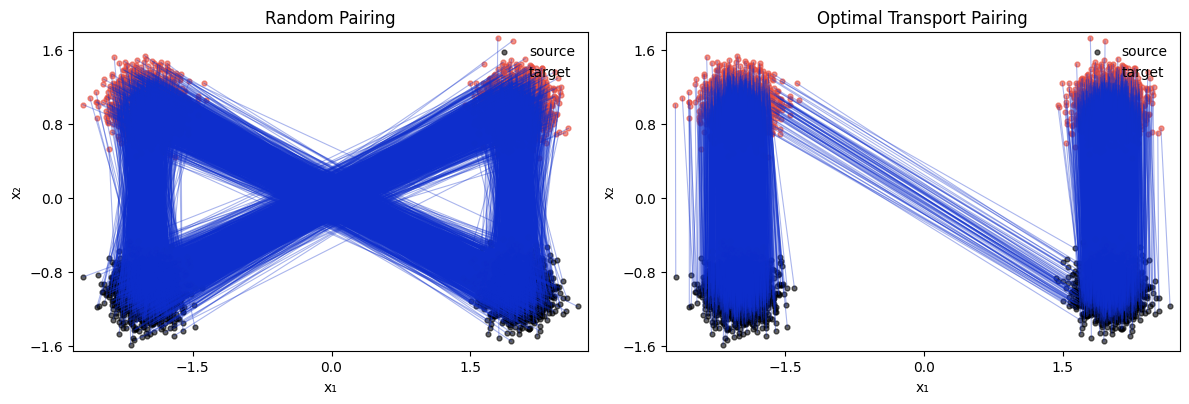

In [5]:
# Compute OT pairing using our function
indices_ot, _ = minibatch_ot_pairing(source_tensor, target_tensor)
assignment_ot = indices_ot.cpu().numpy()

# Random pairing for comparison
perm_random = torch.randperm(target_tensor.shape[0]).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_transport_lines(
    source_np, target_np, perm_random, 
    ax=axes[0], 
    title='Random Pairing', 
    source_color=source_color, 
    target_color=target_color, 
    line_color=line_color
)
plot_transport_lines(
    source_np, target_np, assignment_ot, 
    ax=axes[1], 
    title='Optimal Transport Pairing', 
    source_color=source_color, 
    target_color=target_color, 
    line_color=line_color
)
plt.tight_layout()
plt.show()


Now let's compare random vs. optimal transport pairings. Notice how OT creates shorter, more structured connections that respect the geometric structure:

## Training with Different Pairings


---

First, let's set up our samplers for training.

**🎯 Exercise: Implement OT Pairing in Training**

Before we use the full training utilities, let's understand how OT pairing works by implementing a simplified training loop for the toy example. In the cell below, you'll complete a training function that uses OT pairing - the key difference from random pairing is just **2 lines of code**!

In [ ]:
toy_source_sampler = make_batch_sampler(base_sampler)
toy_target_sampler = make_batch_sampler(target_sampler)

def toy_latent_sampler(shape: tuple[int, ...]) -> torch.Tensor:
    if len(shape) != 2 or shape[1] != 2:
        raise ValueError('Expected latent shape (batch, 2) for the toy example.')
    return toy_source_sampler(shape[0], device=DEVICE, dtype=torch.float32)

# Import the simple model and training utilities from Notebook 01
from fm_utils import VelocityMLP, update_ema
from torch.nn.utils import clip_grad_norm_

def train_toy_with_ot(num_steps=5000, batch_size=128, lr=5e-4):
    """
    Simplified training loop with OT pairing for the toy two-Gaussian example.
    
    This function is almost identical to random pairing training, except for
    the OT pairing step. Your task: complete the 2 TODO sections below.
    """
    set_seed(42)
    
    # Setup model and optimizer (provided)
    model = VelocityMLP(input_dim=2, hidden_dim=64).to(DEVICE)
    ema_model = VelocityMLP(input_dim=2, hidden_dim=64).to(DEVICE)
    ema_model.load_state_dict(model.state_dict())
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    for step in range(num_steps):
        # Sample from target (x0) and source/latent (x1) distributions
        x0 = toy_target_sampler(batch_size, device=DEVICE, dtype=torch.float32)
        x1 = toy_latent_sampler((batch_size, 2))
        
        # TODO 1: Compute OT pairing between x0 and x1
        # Review the minibatch_ot_pairing function signature above
        # What does it return?
        indices, _ = ???  # YOUR CODE HERE
        
        # TODO 2: Reorder x1 according to the optimal transport plan
        # Use the indices from the OT solution to permute x1 to match x0
        x1 = ???  # YOUR CODE HERE
        
        # Rest of the training loop is identical to random pairing (provided)
        t = torch.rand(batch_size, 1, device=DEVICE)
        x_t = (1.0 - t) * x0 + t * x1
        velocity_target = x1 - x0
        
        pred = model(t, x_t)
        loss = ((pred - velocity_target) ** 2).sum(dim=1).mean()
        
        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        update_ema(ema_model, model, 0.9)
        
        losses.append(loss.detach().cpu().item())
        if (step + 1) % 1000 == 0:
            print(f"step {step + 1:5d} | loss = {losses[-1]:.6f}")
    
    return {'model': model, 'ema': ema_model, 'losses': losses}

# Test your implementation
print("Training toy example with OT pairing (your implementation)...")
toy_ot_manual = train_toy_with_ot(num_steps=5000, batch_size=128)
print("✓ Training complete!")

In [ ]:
# Configuration for toy example without OT
toy_config_no_ot = {
    'target_sampler': toy_target_sampler,
    'latent_sampler': toy_latent_sampler,
    'steps': 5000,
    'log_every': 1000,
    'batch_size': 128,
}

print("Training without OT pairing...")
toy_no_ot_run = train_flow(FlowConfig(**toy_config_no_ot))

# Configuration for toy example with OT
toy_config_ot = {
    'target_sampler': toy_target_sampler,
    'latent_sampler': toy_latent_sampler,
    'pairing': 'minibatch_ot',
    'minibatch_ot_fn': minibatch_ot_pairing,
    'steps': 5000,
    'log_every': 1000,
    'batch_size': 128,
}
print("\nTraining with OT pairing...")
toy_ot_run = train_flow(FlowConfig(**toy_config_ot))

Now let's train two models using `train_flow` - one with random pairing and one with OT pairing - to compare with your implementation:

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left plot: Random vs Your OT implementation
axes[0].plot(toy_no_ot_run.losses, color='#D62728', alpha=0.2, linewidth=0.5)
axes[0].plot(compute_ema(toy_no_ot_run.losses), label="Random pairing", color='#D62728', linewidth=2)
axes[0].plot(toy_ot_manual['losses'], color='#2CA02C', alpha=0.2, linewidth=0.5)
axes[0].plot(compute_ema(toy_ot_manual['losses']), label="OT pairing (your implementation)", color='#2CA02C', linewidth=2)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Your Implementation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Random vs train_flow OT
axes[1].plot(toy_no_ot_run.losses, color='#D62728', alpha=0.2, linewidth=0.5)
axes[1].plot(compute_ema(toy_no_ot_run.losses), label="Random pairing", color='#D62728', linewidth=2)
axes[1].plot(toy_ot_run.losses, color='#9467BD', alpha=0.2, linewidth=0.5)
axes[1].plot(compute_ema(toy_ot_run.losses), label="OT pairing (train_flow)", color='#9467BD', linewidth=2)
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("MSE loss")
axes[1].set_title("Reference Implementation")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ If your implementation is correct, both plots should look similar!")

### Visualizing Training Loss

Let's plot the training curves:

In [ ]:
# Random Pairing
latents = toy_no_ot_run.config.latent_sampler((256, 2))
with torch.no_grad():
    trajectories = euler_integrate(toy_no_ot_run.ema, latents, toy_no_ot_run.config.flow_T, steps=120, return_path=True)

target_samples = toy_no_ot_run.config.target_sampler(4096, device=DEVICE, dtype=torch.float32)
combined = torch.cat([target_samples, trajectories[-1], latents], dim=0).detach().cpu().numpy()
x_min, y_min = combined.min(axis=0)
x_max, y_max = combined.max(axis=0)
pad_x = 0.08 * max(x_max - x_min, 1.0)
pad_y = 0.08 * max(y_max - y_min, 1.0)
limits = ((x_min - pad_x, x_max + pad_x), (y_min - pad_y, y_max + pad_y))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_points(axes[0], target_samples, 'Random Pairing: Target', target_color, limits=limits)
plot_points(axes[1], trajectories[-1], 'Random Pairing: Generated', line_color, limits=limits)
plot_points(axes[2], latents, 'Random Pairing: Latent', source_color, limits=limits)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
plot_source_target_trajectories(
    source=latents, trajectories=trajectories, target=trajectories[-1],
    title='Random Pairing: Trajectories', ax=ax,
    latent_color=source_color, endpoint_color=target_color, path_color=line_color
)
plt.tight_layout()
plt.show()

# OT Pairing (your implementation)
latents = toy_latent_sampler((256, 2))
with torch.no_grad():
    trajectories = euler_integrate(toy_ot_manual['ema'], latents, 1.0, steps=120, return_path=True)

target_samples = toy_target_sampler(4096, device=DEVICE, dtype=torch.float32)
combined = torch.cat([target_samples, trajectories[-1], latents], dim=0).detach().cpu().numpy()
x_min, y_min = combined.min(axis=0)
x_max, y_max = combined.max(axis=0)
pad_x = 0.08 * max(x_max - x_min, 1.0)
pad_y = 0.08 * max(y_max - y_min, 1.0)
limits = ((x_min - pad_x, x_max + pad_x), (y_min - pad_y, y_max + pad_y))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_points(axes[0], target_samples, 'OT Pairing: Target', target_color, limits=limits)
plot_points(axes[1], trajectories[-1], 'OT Pairing: Generated', line_color, limits=limits)
plot_points(axes[2], latents, 'OT Pairing: Latent', source_color, limits=limits)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
plot_source_target_trajectories(
    source=latents, trajectories=trajectories, target=trajectories[-1],
    title='OT Pairing: Trajectories', ax=ax,
    latent_color=source_color, endpoint_color=target_color, path_color=line_color
)
plt.tight_layout()
plt.show()

### Visualizing Generated Samples and Trajectories

Let's examine the generated distributions and flow paths for both models:

In [ ]:
# Random Pairing metrics
latents = toy_no_ot_run.config.latent_sampler((2048, 2))
target_samples = toy_no_ot_run.config.target_sampler(2048, device=DEVICE, dtype=torch.float32)
with torch.no_grad():
    generated = euler_integrate(toy_no_ot_run.ema, latents, toy_no_ot_run.config.flow_T, steps=150)
metrics = compute_distribution_metrics(generated, target_samples, blur=0.01)
print("\nRandom Pairing:")
if 'sinkhorn_div' in metrics:
    print(f"  Sinkhorn divergence: {metrics['sinkhorn_div']:.6f}")
print(f"  Mean error: {metrics['mean_error']:.6f}")
print(f"  Std error: {metrics['std_error']:.6f}")

# OT Pairing metrics (your implementation)
latents = toy_latent_sampler((2048, 2))
target_samples = toy_target_sampler(2048, device=DEVICE, dtype=torch.float32)
with torch.no_grad():
    generated = euler_integrate(toy_ot_manual['ema'], latents, 1.0, steps=150)
metrics = compute_distribution_metrics(generated, target_samples, blur=0.01)
print("\nOT Pairing (your implementation):")
if 'sinkhorn_div' in metrics:
    print(f"  Sinkhorn divergence: {metrics['sinkhorn_div']:.6f}")
print(f"  Mean error: {metrics['mean_error']:.6f}")
print(f"  Std error: {metrics['std_error']:.6f}")

### Quantitative Evaluation

Let's compute distribution metrics to quantify the quality of the learned flows:

## Another Synthetic Example: Two Moons Distribution

Let's apply OT pairing to another 2D distribution - the two moons - to explore how it affects training on complex, curved manifolds.

---

In [11]:
two_moons_distribution = get_distribution("twomoons")
two_moons_sampler = make_batch_sampler(two_moons_distribution)
latent_sampler = make_latent_sampler("gaussian", DEVICE, 2)

# Configuration for training without OT
config_no_ot = {
    'target_sampler': two_moons_sampler,
    'latent_sampler': latent_sampler,
    'steps': 15000,
    'log_every': 500,
    'batch_size': 128,
}

print("Training without OT pairing...")
no_ot_run = train_flow(FlowConfig(**config_no_ot))

# Configuration for training with OT
config_ot = {
    'target_sampler': two_moons_sampler,
    'latent_sampler': latent_sampler,
    'pairing': 'minibatch_ot',
    'minibatch_ot_fn': minibatch_ot_pairing,
    'steps': 15000,
    'log_every': 500,
    'batch_size': 128,
}

print("\nTraining with minibatch OT pairing...")
ot_run = train_flow(FlowConfig(**config_ot))

Training without OT pairing...
step   500 | loss = 2.311158
step  1000 | loss = 2.114669
step  1500 | loss = 1.951148
step  2000 | loss = 1.922011
step  2500 | loss = 2.115136
step  3000 | loss = 1.901209
step  3500 | loss = 1.901357
step  4000 | loss = 2.085080
step  4500 | loss = 2.169655
step  5000 | loss = 2.266443
step  5500 | loss = 2.337948
step  6000 | loss = 1.790110
step  6500 | loss = 1.940252
step  7000 | loss = 1.866778
step  7500 | loss = 2.371399
step  8000 | loss = 2.078743
step  8500 | loss = 1.971480
step  9000 | loss = 2.025793
step  9500 | loss = 2.042957
step 10000 | loss = 2.309421
step 10500 | loss = 2.042576
step 11000 | loss = 2.041883
step 11500 | loss = 2.110446
step 12000 | loss = 1.935701
step 12500 | loss = 1.826737
step 13000 | loss = 1.776751
step 13500 | loss = 2.012406
step 14000 | loss = 1.726363
step 14500 | loss = 1.952922
step 15000 | loss = 1.785447

Training with minibatch OT pairing...
step   500 | loss = 0.235705 | OT cost ≈ 0.6758
step  1000 |

Let's set up samplers and train both models on the two moons dataset:

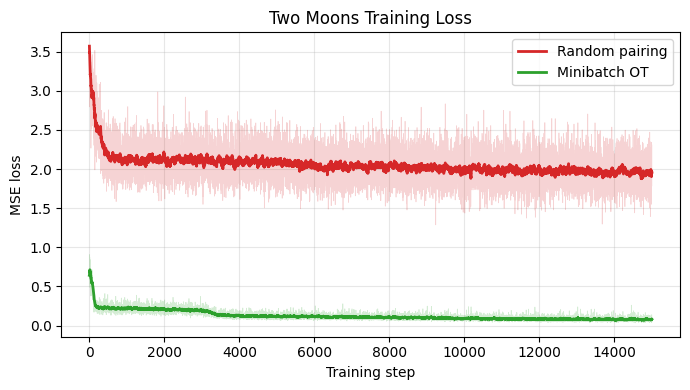

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

# Random pairing
ax.plot(no_ot_run.losses, color='#D62728', alpha=0.2, linewidth=0.5)
ax.plot(compute_ema(no_ot_run.losses), label="Random pairing", color='#D62728', linewidth=2)

# Minibatch OT
ax.plot(ot_run.losses, color='#2CA02C', alpha=0.2, linewidth=0.5)
ax.plot(compute_ema(ot_run.losses), label="Minibatch OT", color='#2CA02C', linewidth=2)

ax.set_xlabel("Training step")
ax.set_ylabel("MSE loss")
ax.set_title("Two Moons Training Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Training Loss Comparison

Let's compare the training dynamics:

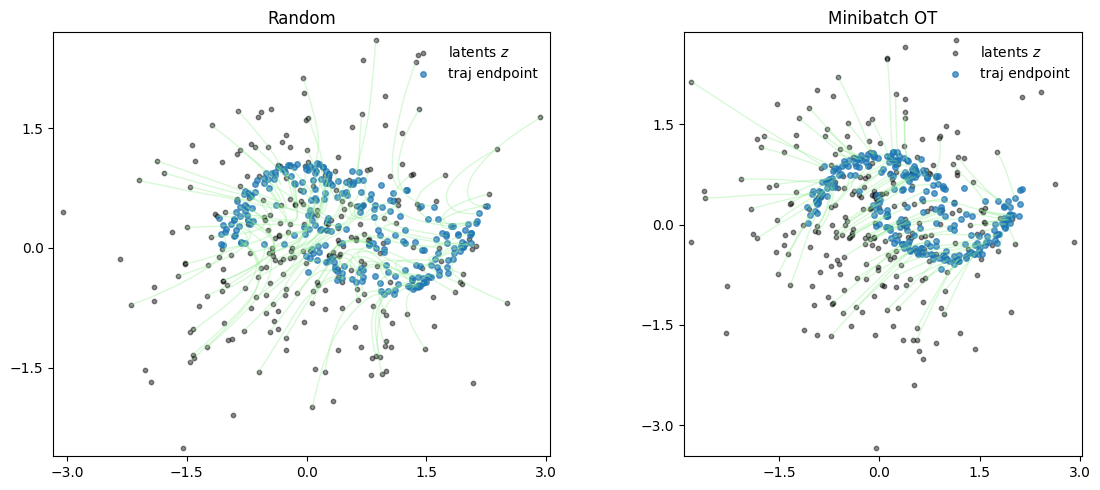

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random pairing trajectories
latents = no_ot_run.config.latent_sampler((256, 2))
with torch.no_grad():
    trajectories = euler_integrate(no_ot_run.ema, latents, no_ot_run.config.flow_T, steps=120, return_path=True)
plot_source_target_trajectories(
    source=latents, trajectories=trajectories, target=trajectories[-1],
    title="Random", ax=axes[0],
    latent_color="#000000", endpoint_color="#1f77b4", path_color="#90EE90"
)

# Minibatch OT trajectories
latents = ot_run.config.latent_sampler((256, 2))
with torch.no_grad():
    trajectories = euler_integrate(ot_run.ema, latents, ot_run.config.flow_T, steps=120, return_path=True)
plot_source_target_trajectories(
    source=latents, trajectories=trajectories, target=trajectories[-1],
    title="Minibatch OT", ax=axes[1],
    latent_color="#000000", endpoint_color="#1f77b4", path_color="#90EE90"
)

plt.tight_layout()
plt.show()

### Flow Trajectories

Let's visualize the learned flow paths:

In [14]:
# Random pairing metrics
latents = no_ot_run.config.latent_sampler((2048, 2))
target_samples = two_moons_sampler(2048, device=DEVICE, dtype=torch.float32)
with torch.no_grad():
    generated = euler_integrate(no_ot_run.ema, latents, no_ot_run.config.flow_T, steps=150)
metrics = compute_distribution_metrics(generated, target_samples, blur=0.01)
print("\nRandom:")
if 'sinkhorn_div' in metrics:
    print(f"  Sinkhorn divergence: {metrics['sinkhorn_div']:.6f}")
print(f"  Mean error: {metrics['mean_error']:.6f}")
print(f"  Std error: {metrics['std_error']:.6f}")

# Minibatch OT metrics
latents = ot_run.config.latent_sampler((2048, 2))
target_samples = two_moons_sampler(2048, device=DEVICE, dtype=torch.float32)
with torch.no_grad():
    generated = euler_integrate(ot_run.ema, latents, ot_run.config.flow_T, steps=150)
metrics = compute_distribution_metrics(generated, target_samples, blur=0.01)
print("\nMinibatch OT:")
if 'sinkhorn_div' in metrics:
    print(f"  Sinkhorn divergence: {metrics['sinkhorn_div']:.6f}")
print(f"  Mean error: {metrics['mean_error']:.6f}")
print(f"  Std error: {metrics['std_error']:.6f}")


Random:
  Sinkhorn divergence: 0.005444
  Mean error: 0.027130
  Std error: 0.014004

Minibatch OT:
  Sinkhorn divergence: 0.004110
  Mean error: 0.027686
  Std error: 0.008633


### Quantitative Metrics

Let's compute distribution quality metrics:


## Questions to Consider

- Compare the training losses and sample quality between random and OT pairing. What differences do you observe?
- Look at the flow trajectories. What characterizes the paths learned with OT vs. random pairing?
- Does solving an optimal transport problem at every training step add significant computational overhead? When might it be worth it?

### Next: Conditional Flow Matching

In the next notebook, we'll explore conditional flow matching and see how these pairing principles extend to the conditional setting with Y-penalized OT.


---